# Variational Inference - simple example

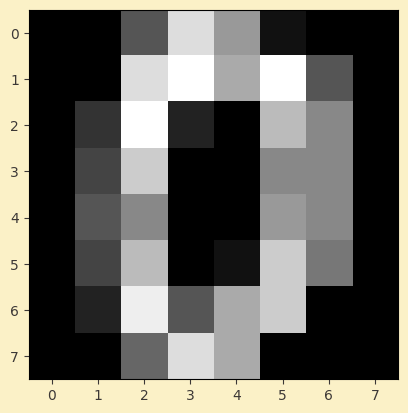

In [ ]:
from sklearn import datasets
import matplotlib.pyplot as plt
import torch
import torch.distributions as dist
import torch.nn.functional as F


digits = datasets.load_digits()
is_zero = digits.target == 0
X_train_np = digits.images[is_zero]

n_pixels = X_train_np.shape[1] * X_train_np.shape[2]
X_train_np = X_train_np.reshape((-1, n_pixels))
X_train = torch.tensor(X_train_np, dtype=torch.float32)

plt.imshow(X_train[0].reshape(8, 8), cmap='gray')

# Assumptions

Assume $z$ - a latent representation (rate), $x$ - image

$$
p(x\mid z) = Poisson(x \mid rate=z)
$$

$Gamma$ is a conjugate prior for $Poisson$ therefore

$$
p(z) = Gamma(z\mid a, b)
$$

So

$$
p(z\mid x) = Gamma(z \mid a', b') \propto p(x\mid z) p(z)
$$


In [169]:
x0 = X_train[0]
a = torch.clamp(2 * x0, min=1e-6)
b = torch.tensor(2.0)
gamma_prior = dist.Gamma(concentration=a, rate=b)

def log_joint(z):
    z_expanded = z.unsqueeze(1)
    poisson_likelihood = dist.Poisson(rate=z_expanded)
    log_likelihood = torch.sum(poisson_likelihood.log_prob(X_train), dim=(1, 2))
    log_prior = torch.sum(gamma_prior.log_prob(z), dim=-1)
    return log_prior + log_likelihood


# Variational model

$$
q(z) = Gamma(z \mid \alpha, \beta)
$$

Optimize ELBO

$$ 
\text{ELBO} = \underbrace{\mathbb{E}_{q(z)} [\log p(x \mid z)]}_{\text{Reconstruction}} - \underbrace{D_{KL}(q(z) \parallel p(z))}_{\text{Regularization}}
$$

Reconstruction - given $z$, does this reconstruct $x$ well


In [170]:
# ELBO = E_q[log p(x, z)] - E_q[log q(z)]
# logprob(x,z) = reconstructed image + prior
# logprob(q) = logprob of the variational distribution

def evidence_lower_bound(theta_samples, alpha, inv_beta):
    beta = 1.0 / inv_beta
    q_dist = dist.Gamma(concentration=alpha, rate=beta)
    log_q = torch.sum(q_dist.log_prob(theta_samples), dim=-1)
    elbo = log_joint(theta_samples) - log_q
    return elbo

def loss(phi: dict, batch_size=128):
    alpha = torch.exp(phi['log_alpha'])
    inv_beta = torch.exp(-phi['log_beta'])
    beta = 1.0 / inv_beta
    q_dist = dist.Gamma(concentration=alpha, rate=beta)
    theta_samples = q_dist.rsample(sample_shape=torch.Size([batch_size]))
    elbo_loss = torch.mean(evidence_lower_bound(theta_samples, alpha, inv_beta))
    return -elbo_loss

# Optimization

In [171]:
n_pixels = 64
epochs = 1000
batch_size = 128

phi = {
    'log_alpha': torch.randn(n_pixels, requires_grad=True),
    'log_beta': torch.randn(n_pixels, requires_grad=True)
}

optimizer = torch.optim.Adam(list(phi.values()), lr=0.01)

for epoch in range(epochs):
    optimizer.zero_grad()
    
    negative_elbo = loss(phi, batch_size=batch_size)
    negative_elbo.backward()
    torch.nn.utils.clip_grad_norm_(list(phi.values()), max_norm=1.0)
    
    optimizer.step()
    
    if epoch % 100 == 0:
        print(f"Epoch {epoch:4d} | Loss (Negative ELBO): {negative_elbo.item():.4f}")

print("Optimization Complete.")

final_alpha = torch.exp(phi['log_alpha']).detach()
final_inv_beta = torch.exp(-phi['log_beta']).detach()

print("Params Alpha:\n", final_alpha)
print("Params Inv_Beta:\n", final_inv_beta)


Epoch    0 | Loss (Negative ELBO): 146344.1250
Epoch  100 | Loss (Negative ELBO): 45073.8828
Epoch  200 | Loss (Negative ELBO): 25179.8301
Epoch  300 | Loss (Negative ELBO): 22148.5977
Epoch  400 | Loss (Negative ELBO): 21278.5312
Epoch  500 | Loss (Negative ELBO): 20780.4648
Epoch  600 | Loss (Negative ELBO): 20553.1309
Epoch  700 | Loss (Negative ELBO): 20400.1094
Epoch  800 | Loss (Negative ELBO): 20294.9199
Epoch  900 | Loss (Negative ELBO): 20210.8262
Optimization Complete.
Params Alpha:
 tensor([3.0270e-08, 4.0345e+00, 9.6277e+01, 9.7355e+01, 1.2933e+02, 4.7569e+01,
        5.7701e+00, 6.2120e-06, 1.4490e-04, 7.8289e+01, 1.7843e+02, 9.1822e+01,
        1.3235e+02, 1.5109e+02, 7.6131e+01, 6.3333e-05, 1.0561e-07, 1.0695e+02,
        1.7557e+02, 1.8933e+02, 9.9763e+01, 1.4215e+02, 1.8159e+02, 1.0615e-06,
        7.2794e-03, 1.1772e+02, 1.2557e+02, 8.5863e+01, 1.1802e+01, 1.4480e+02,
        1.2319e+02, 7.0761e-03, 1.7500e-03, 1.5376e+02, 1.8524e+02, 9.1923e+01,
        7.7717e+00, 1

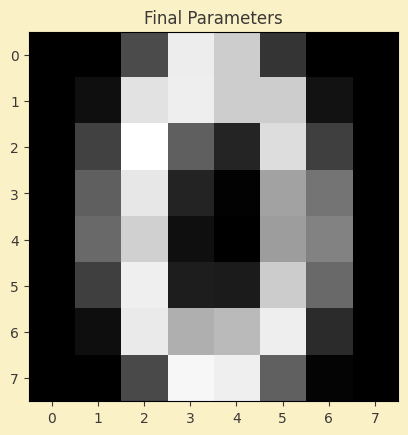

In [172]:
plt.imshow((final_alpha * final_inv_beta).reshape(8, 8).numpy(), cmap='gray')
plt.title("Final Parameters")
plt.show()

# Closed-form posterior comparison

For these simple distributions we can compute closed form of the posterior

$$
p(z/x) = Gamma(z\mid a + \sum x,b + N)
$$

In [173]:
sum_x = X_train.sum(dim=0)
N = X_train.shape[0]
a_exact = a + sum_x
b_exact = b + N

print((a_exact / b_exact).mean())
print((final_alpha * final_inv_beta).mean())


tensor(4.9482)
tensor(4.9622)


# Final distribution

From the final distribution we can:
- sample intensities $q(z)$
- compute **credible** intervals
- check posterior predictive
- detect anomalies


## 1. Sample intensities

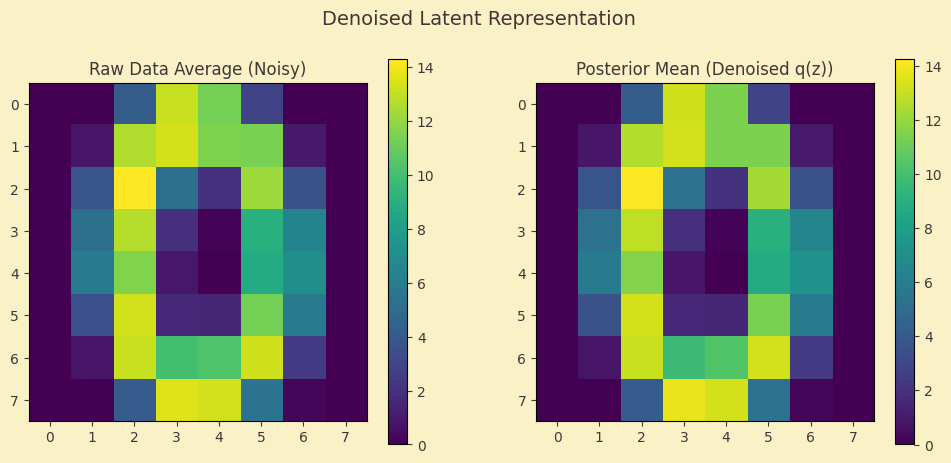

In [ ]:
import numpy as np

q_z = dist.Gamma(concentration=final_alpha, rate=1.0 / final_inv_beta)

z_mean = q_z.mean

grid_size = int(np.sqrt(64))
z_mean_grid = z_mean.view(grid_size, grid_size).numpy()
raw_mean_grid = X_train.mean(dim=0).view(grid_size, grid_size).numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im1 = axes[0].imshow(raw_mean_grid, cmap='viridis')
axes[0].set_title("Raw Data Average (Noisy)")
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(z_mean_grid, cmap='viridis')
axes[1].set_title("Posterior Mean (Denoised q(z))")
plt.colorbar(im2, ax=axes[1])

plt.suptitle("Denoised Latent Representation", fontsize=14)
plt.show()

## 2. Credible intervals

Credible interval covers $p$ probability mass

$$
P(z_l \le z < z_h) = p
$$

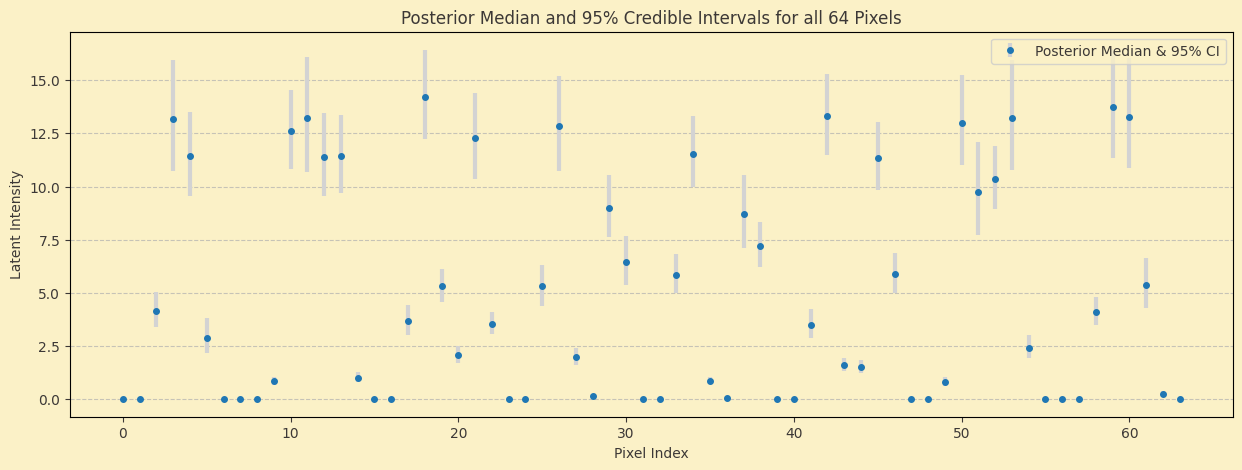

In [180]:
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt

alpha_np = final_alpha.numpy()
scale_np = final_inv_beta.numpy()

lower_bound = stats.gamma.ppf(0.025, a=alpha_np, scale=scale_np)
median_val = stats.gamma.ppf(0.500, a=alpha_np, scale=scale_np)
upper_bound = stats.gamma.ppf(0.975, a=alpha_np, scale=scale_np)

pixels = np.arange(64)

y_err_lower = np.clip(median_val - lower_bound, a_min=0.0, a_max=None)
y_err_upper = np.clip(upper_bound - median_val, a_min=0.0, a_max=None)
y_err = [y_err_lower, y_err_upper]

plt.figure(figsize=(15, 5))
plt.errorbar(pixels, median_val, yerr=y_err, fmt='o', 
             ecolor='lightgray', elinewidth=3, capsize=0, 
             markersize=4, label='Posterior Median & 95% CI')

plt.title("Posterior Median and 95% Credible Intervals for all 64 Pixels")
plt.xlabel("Pixel Index")
plt.ylabel("Latent Intensity")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 3. Posterior Predictive

$$
p(x'|\mathcal{D}) = \int_{\Omega z} p(x' \mid z) p(z \mathcal{D}) dz \approx \int_{\Omega z} p(x' \mid z) q(z) dz = \sum_{z \sim q(z)} p(x' \mid z) 
$$

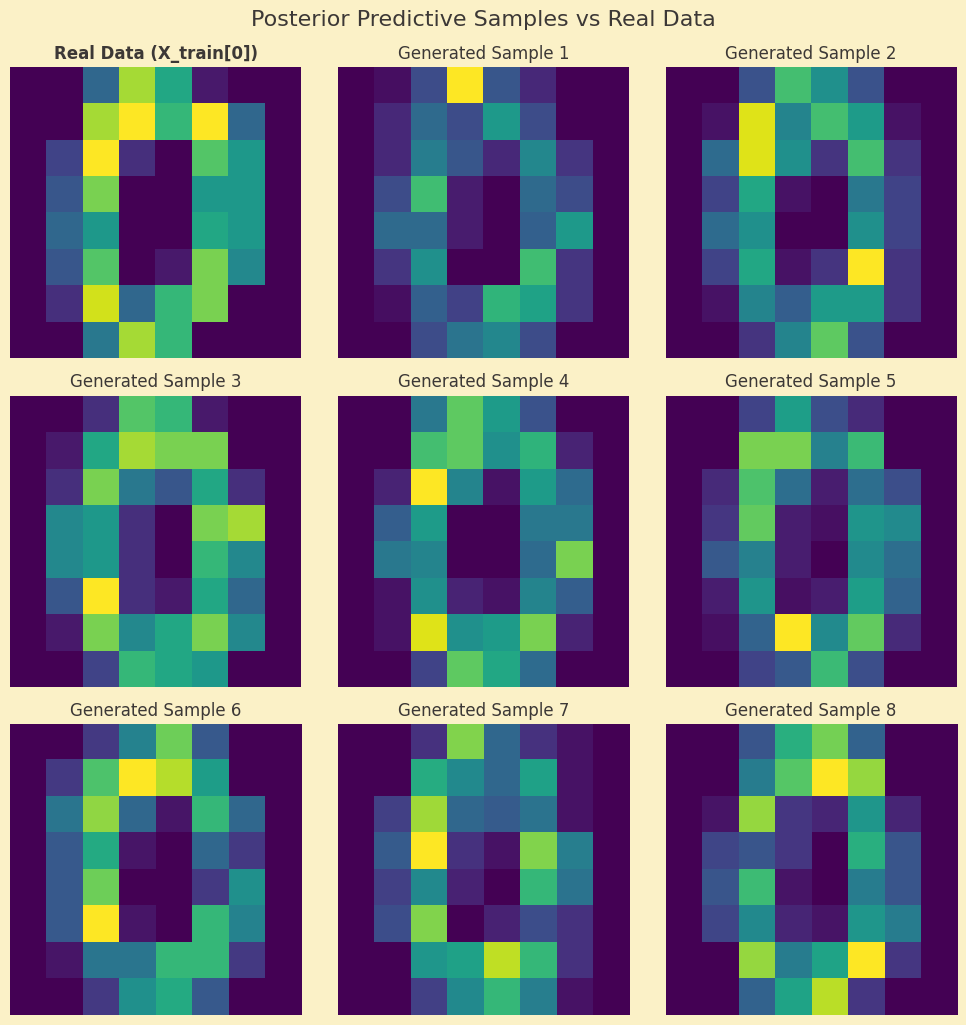

In [ ]:
q_z = dist.Gamma(concentration=final_alpha, rate=1.0 / final_inv_beta)
z_samples = q_z.sample((8,))
x_simulated = dist.Poisson(rate=z_samples).sample()
grid_size = int(np.sqrt(64))
simulated_grids = x_simulated.view(8, grid_size, grid_size).numpy()
real_sample = X_train[0].view(grid_size, grid_size).numpy()
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
axes = axes.flatten()

axes[0].imshow(real_sample, cmap='viridis')
axes[0].set_title("Real Data (X_train[0])", fontweight='bold')
axes[0].axis('off')

for i in range(8):
    ax = axes[i + 1]
    ax.imshow(simulated_grids[i], cmap='viridis')
    ax.set_title(f"Generated Sample {i + 1}")
    ax.axis('off')

plt.tight_layout()
plt.suptitle("Posterior Predictive Samples vs Real Data", fontsize=16, y=1.02)
plt.show()

# Source

https://medium.com/data-science/variational-inference-the-basics-f70ac511bcea